In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.models import Model

from tensorflow.keras.utils import load_img, img_to_array, plot_model

In [2]:
from keras.applications.vgg16 import VGG16

model = VGG16()

I0000 00:00:1790775555.840449      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790775555.847035      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [3]:
model = VGG16(
    weights='imagenet',
    include_top=True
)

model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

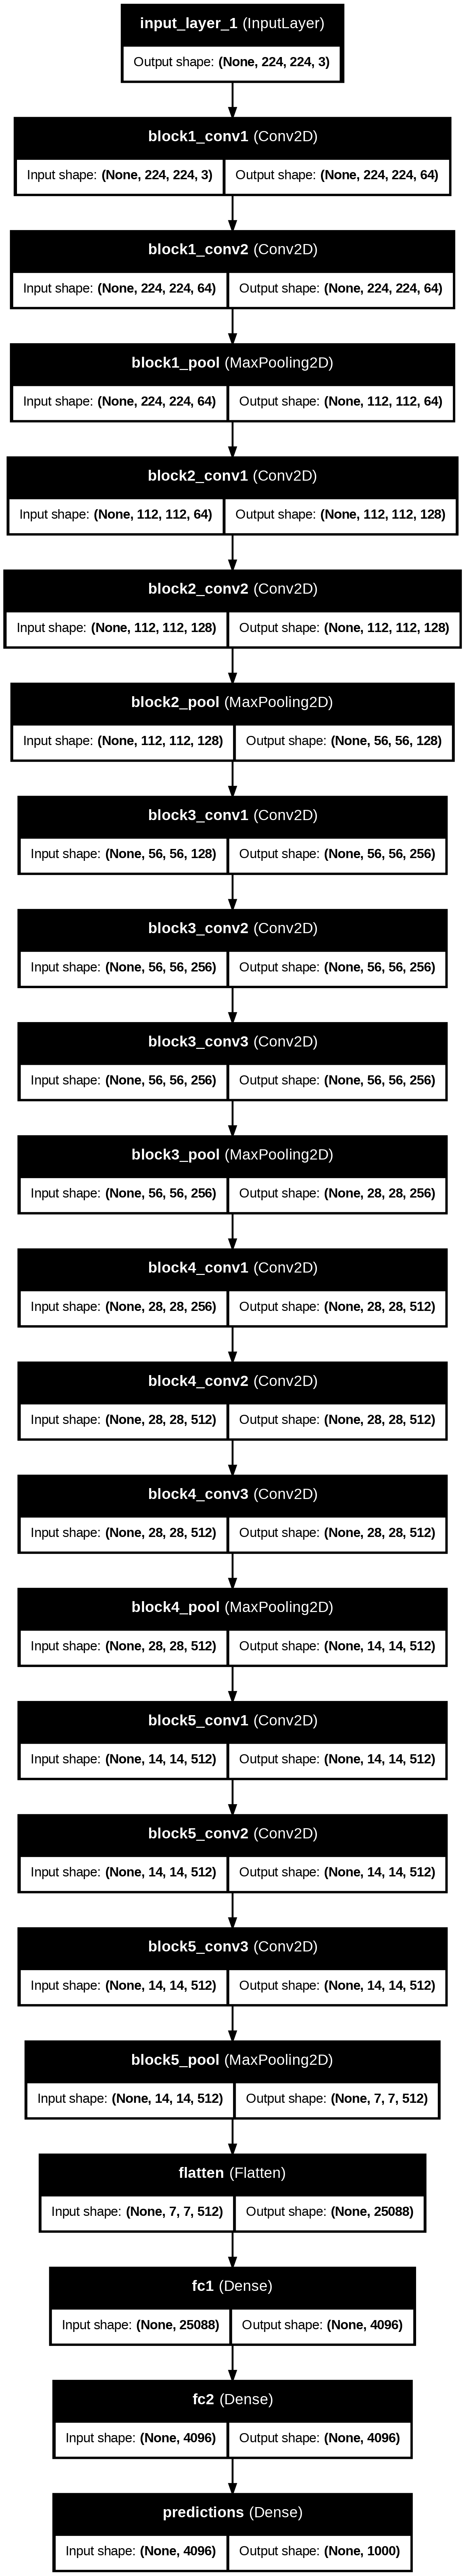

In [4]:
plot_model(
    model,
    show_shapes=True,
    show_layer_names=True
)

##  FILTER VISUALIZATION (FIRST LAYER)

In [5]:
for i, layer in enumerate(model.layers):

    if 'conv' not in layer.name:
        continue

    filters, biases = layer.get_weights()

    print(
        "Layer number:",
        i,
        "| Layer name:",
        layer.name,
        "| Filter shape:",
        filters.shape
    )

Layer number: 1 | Layer name: block1_conv1 | Filter shape: (3, 3, 3, 64)
Layer number: 2 | Layer name: block1_conv2 | Filter shape: (3, 3, 64, 64)
Layer number: 4 | Layer name: block2_conv1 | Filter shape: (3, 3, 64, 128)
Layer number: 5 | Layer name: block2_conv2 | Filter shape: (3, 3, 128, 128)
Layer number: 7 | Layer name: block3_conv1 | Filter shape: (3, 3, 128, 256)
Layer number: 8 | Layer name: block3_conv2 | Filter shape: (3, 3, 256, 256)
Layer number: 9 | Layer name: block3_conv3 | Filter shape: (3, 3, 256, 256)
Layer number: 11 | Layer name: block4_conv1 | Filter shape: (3, 3, 256, 512)
Layer number: 12 | Layer name: block4_conv2 | Filter shape: (3, 3, 512, 512)
Layer number: 13 | Layer name: block4_conv3 | Filter shape: (3, 3, 512, 512)
Layer number: 15 | Layer name: block5_conv1 | Filter shape: (3, 3, 512, 512)
Layer number: 16 | Layer name: block5_conv2 | Filter shape: (3, 3, 512, 512)
Layer number: 17 | Layer name: block5_conv3 | Filter shape: (3, 3, 512, 512)


## FEATURE MAP GENERATION (SINGLE LAYER)

In [6]:
model.layers[1]

<Conv2D name=block1_conv1, built=True>

In [7]:
filters, biases = model.layers[1].get_weights()

print("Filter shape:", filters.shape)
print("Bias shape:", biases.shape)

Filter shape: (3, 3, 3, 64)
Bias shape: (64,)


In [8]:
f_min = filters.min()
f_max = filters.max()

filters = (filters - f_min) / (f_max - f_min)

print(filters.min())
print(filters.max())

0.0
1.0


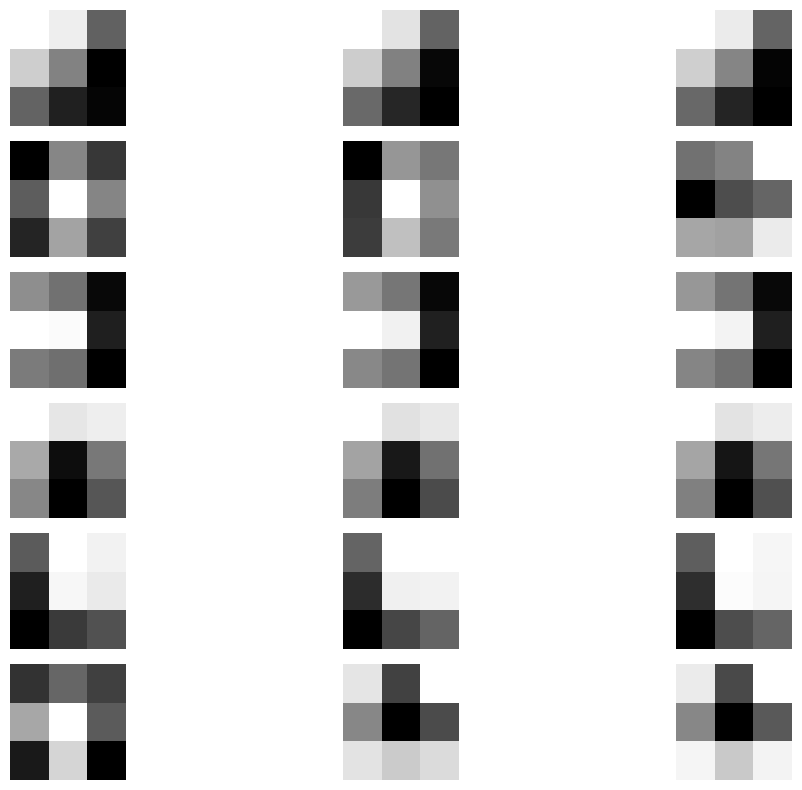

In [9]:
n_filters = 6

fig = plt.figure(figsize=(12, 8))

ix = 1

for i in range(n_filters):

    # Get one filter
    f = filters[:, :, :, i]

    for j in range(3):

        plt.subplot(n_filters, 3, ix)

        plt.imshow(
            f[:, :, j],
            cmap='gray'
        )

        plt.axis('off')

        ix += 1

plt.tight_layout()
plt.show()

In [10]:
feature_model = Model(
    inputs=model.input,
    outputs=model.layers[1].output
)

In [11]:
image_path = "/kaggle/input/datasets/naveenkumartiwari/cat-image/cute-ginger-cat-sitting-looking-camera-isolated-white-background_270100-2630.avif"

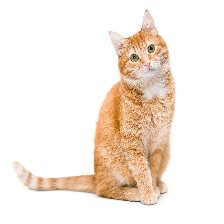

In [12]:
image = load_img(
    image_path,
    target_size=(224, 224)
)

image

In [13]:
image_array = img_to_array(image)

print(image_array.shape)

(224, 224, 3)


In [14]:
image_array = np.expand_dims(
    image_array,
    axis=0
)

print(image_array.shape)

(1, 224, 224, 3)


In [15]:
image_array = preprocess_input(image_array)

In [16]:
features = feature_model.predict(image_array)

print(features.shape)

2026-09-30 13:39:30.437792: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=3,k3=0} for conv (f32[1,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,3,224,224]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-09-30 13:39:31.349221: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.911566993s
Trying algorithm eng11{k2=3,k3=0} for conv (f32[1,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,3,224,224]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convB

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
(1, 224, 224, 64)


I0000 00:00:1790775571.691859      70 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


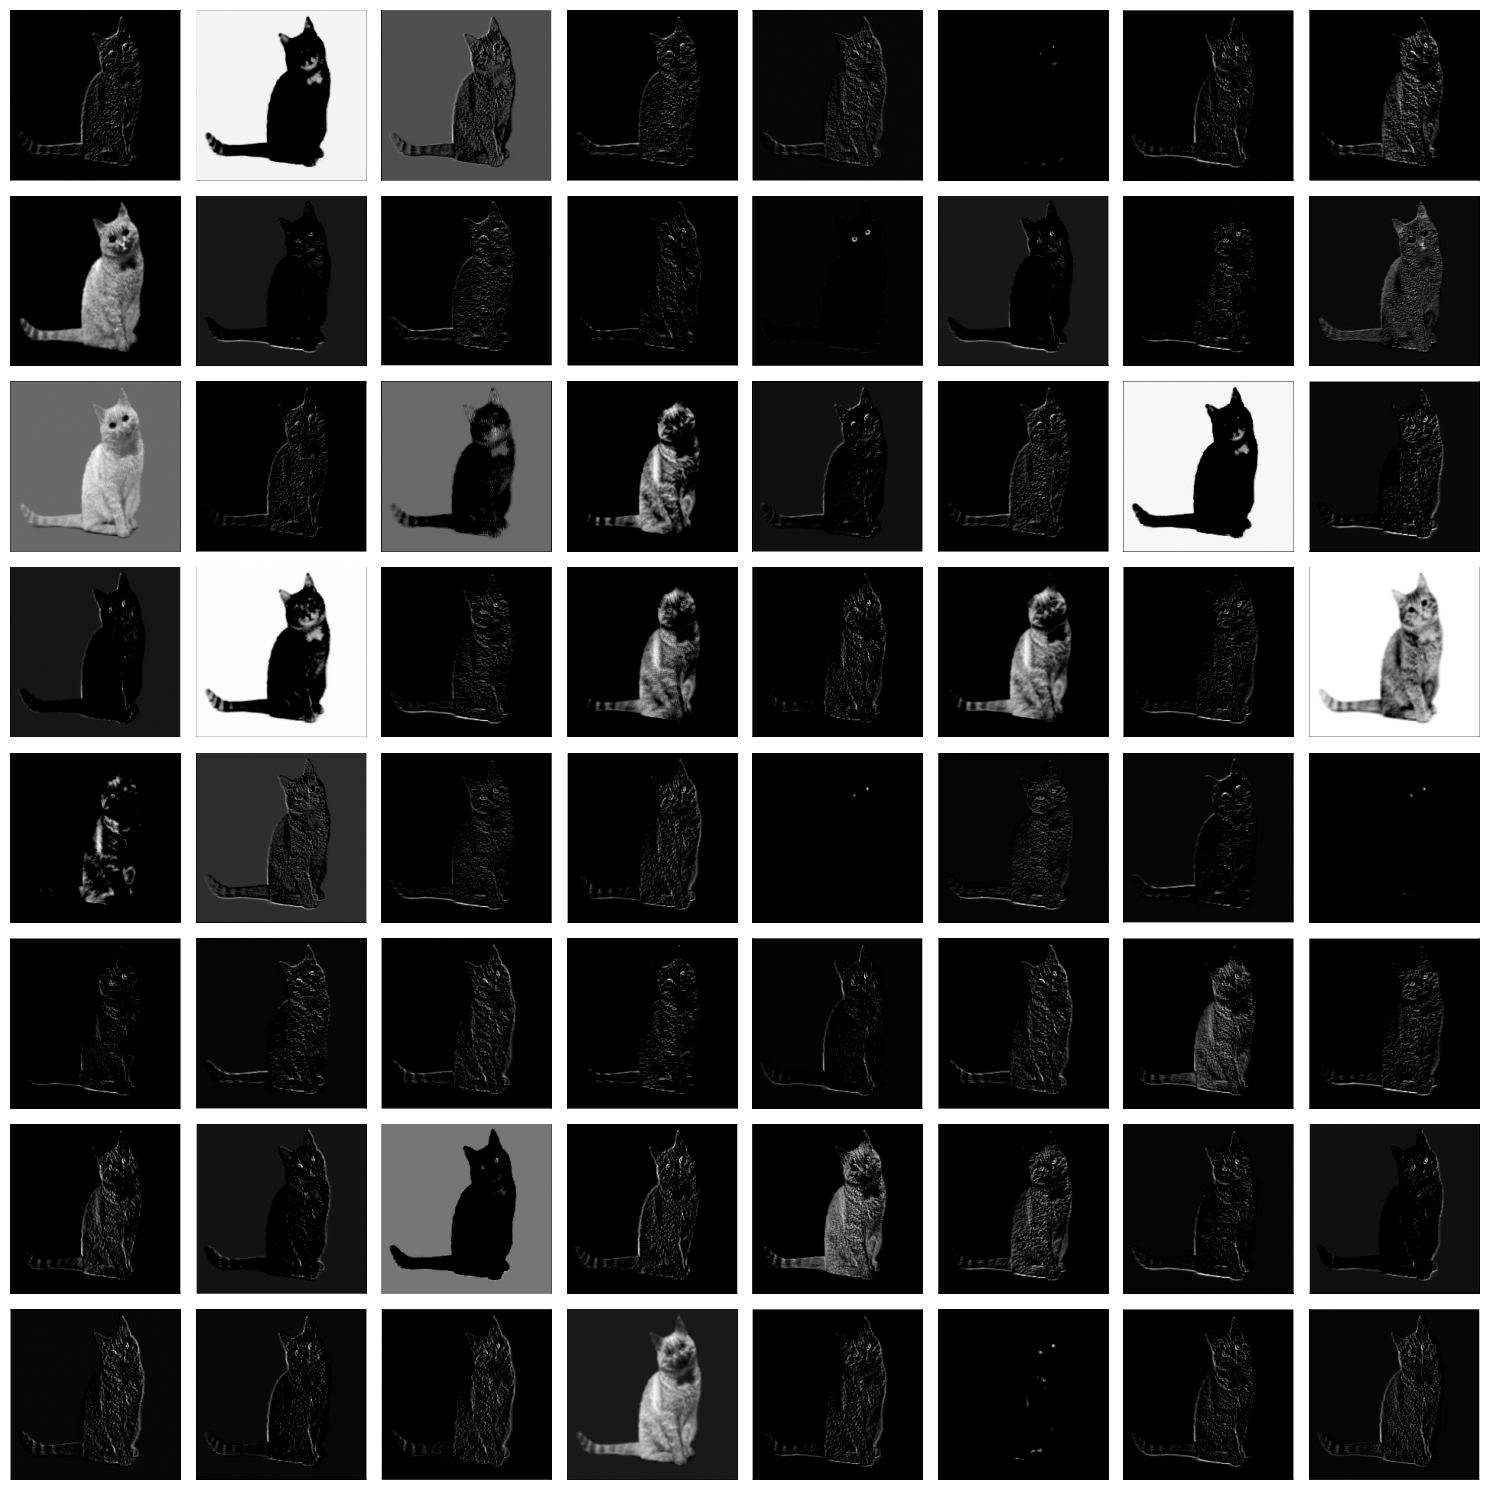

In [17]:
fig = plt.figure(figsize=(15, 15))

for i in range(64):

    plt.subplot(8, 8, i + 1)

    plt.imshow(
        features[0, :, :, i],
        cmap='gray'
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [18]:
layer_indices = [2, 5, 9, 13, 17]

outputs = [
    model.layers[i].output
    for i in layer_indices
]

multi_layer_model = Model(
    inputs=model.input,
    outputs=outputs
)

In [19]:
feature_maps = multi_layer_model.predict(image_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [20]:
for index, fmap in zip(layer_indices, feature_maps):

    print(
        model.layers[index].name,
        fmap.shape
    )

block1_conv2 (1, 224, 224, 64)
block2_conv2 (1, 112, 112, 128)
block3_conv3 (1, 56, 56, 256)
block4_conv3 (1, 28, 28, 512)
block5_conv3 (1, 14, 14, 512)


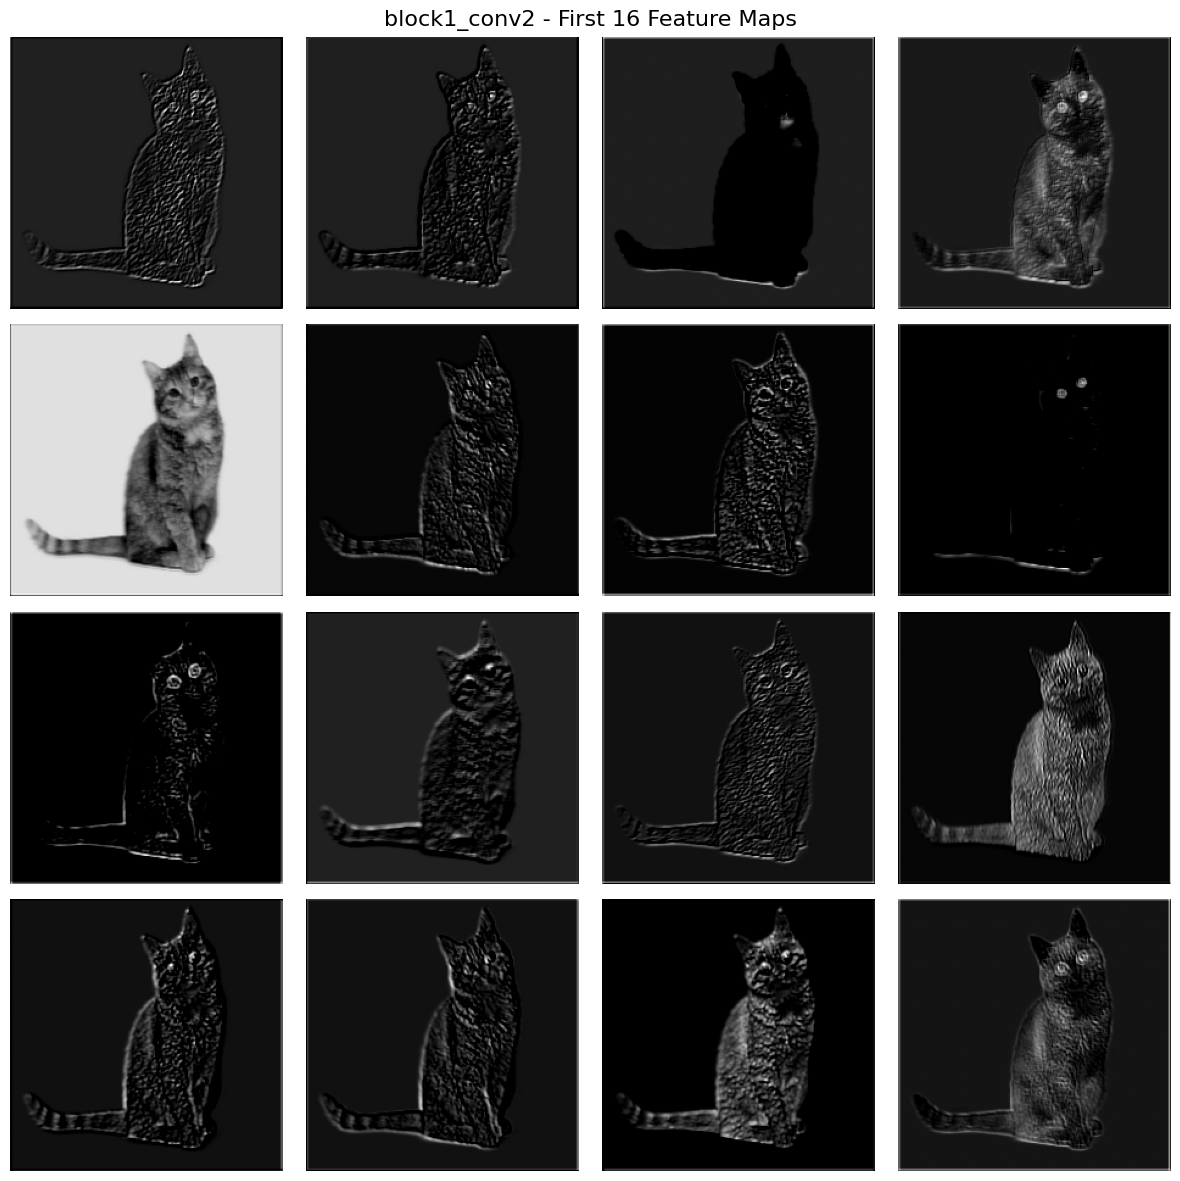

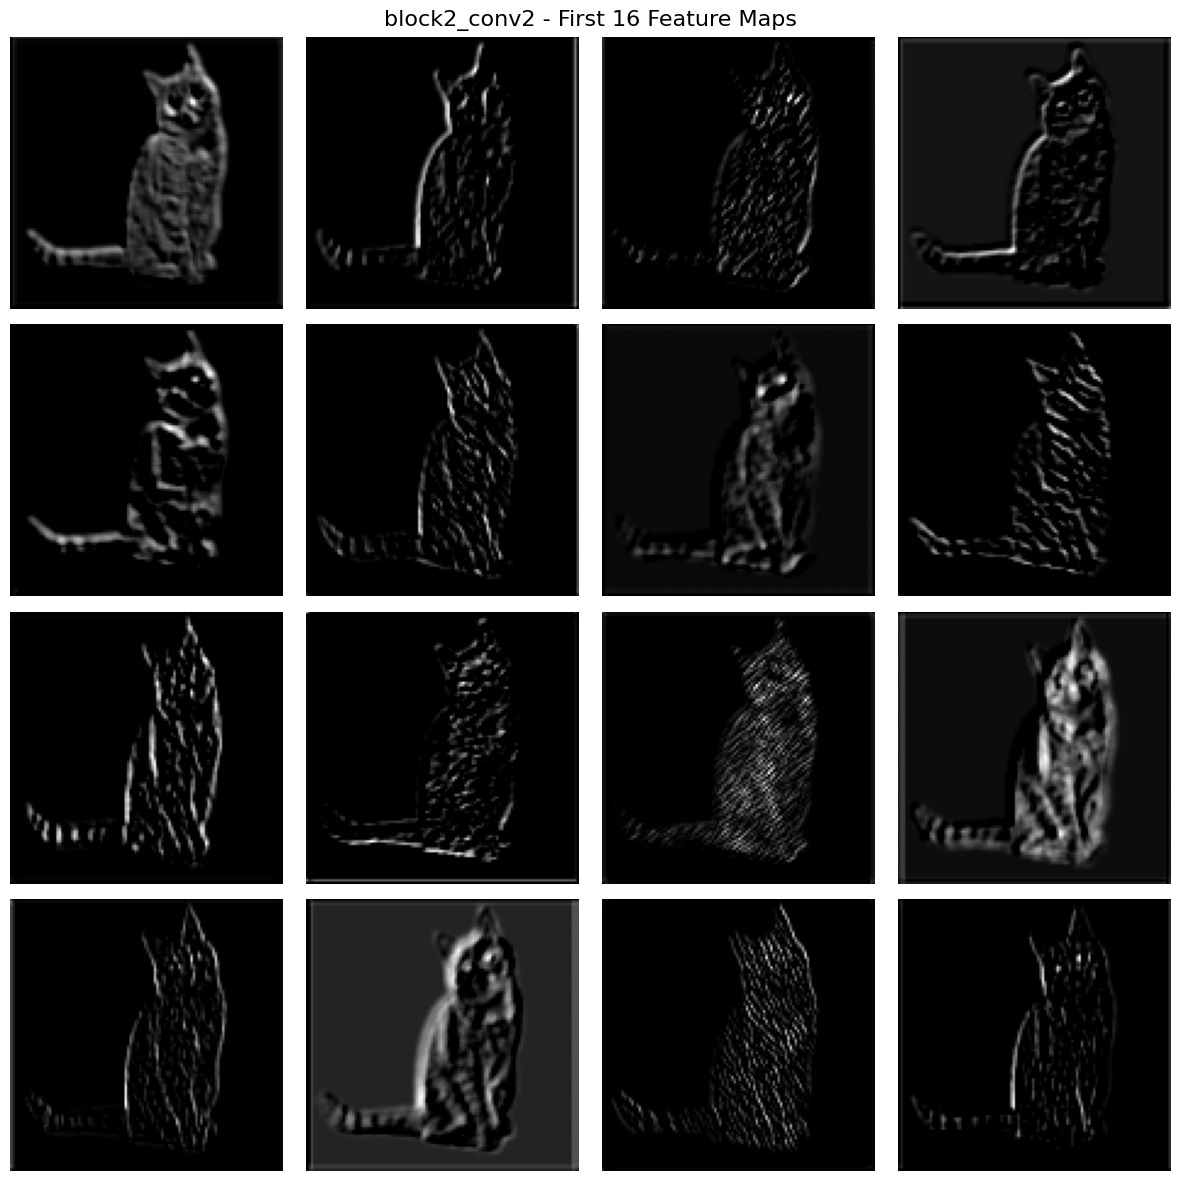

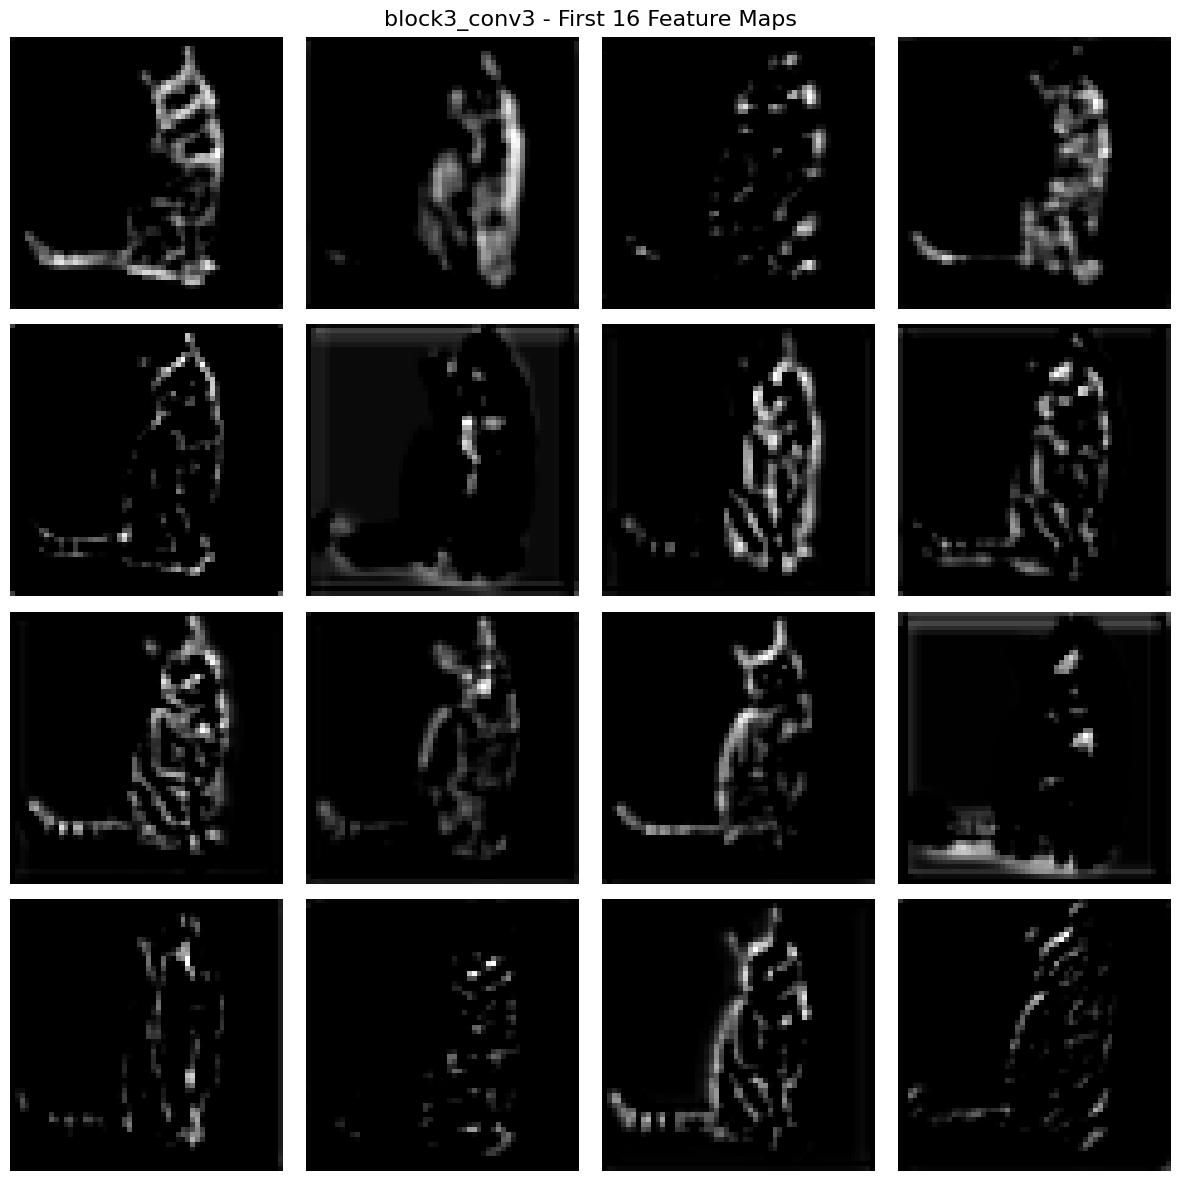

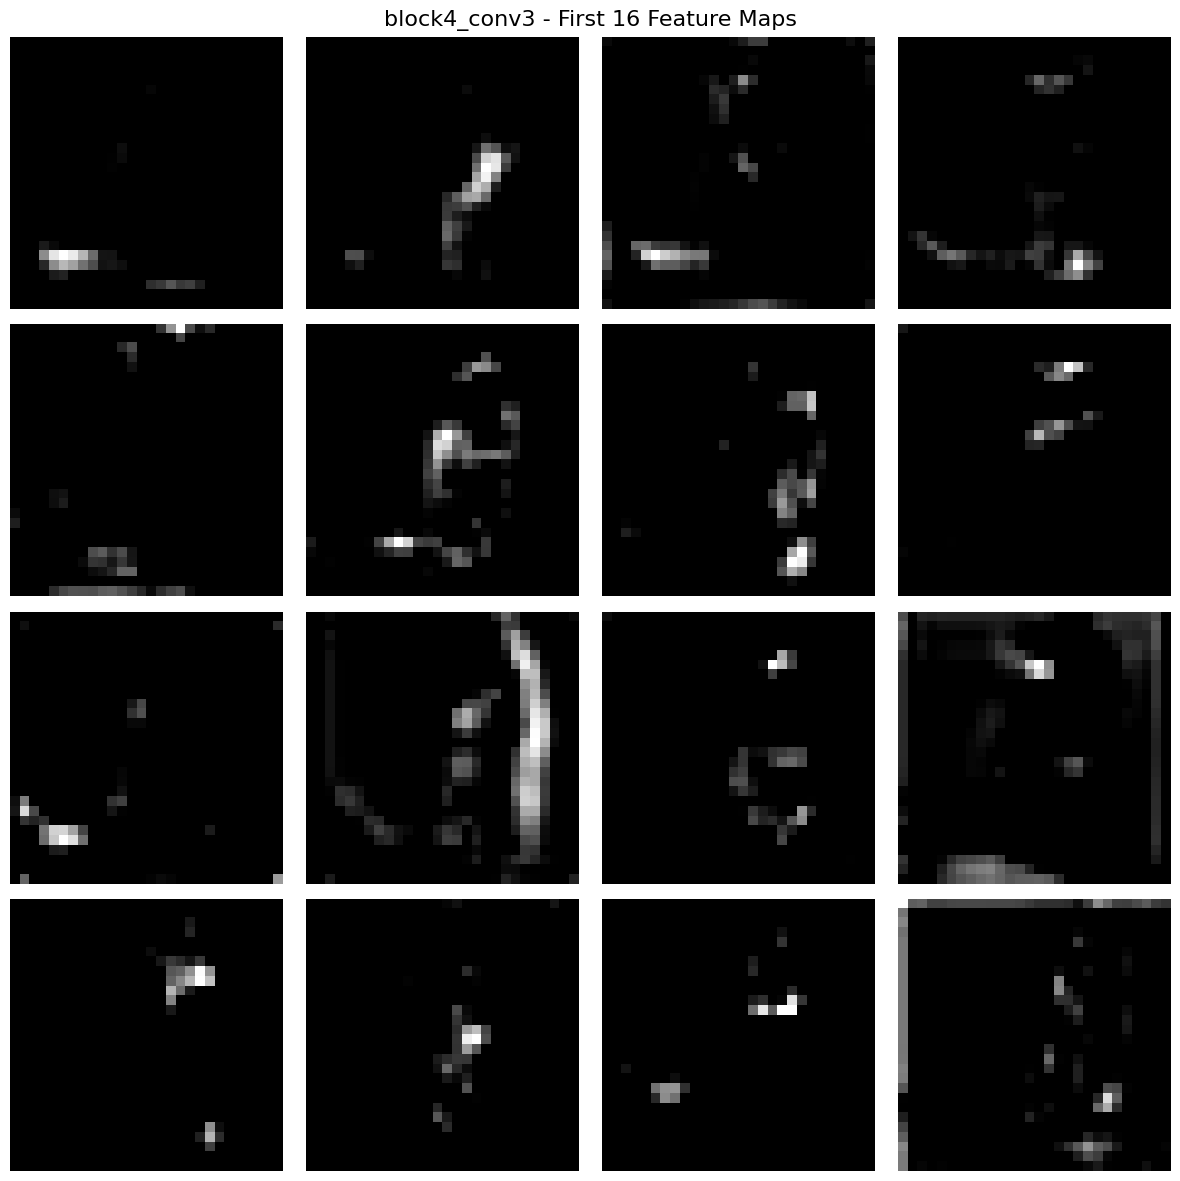

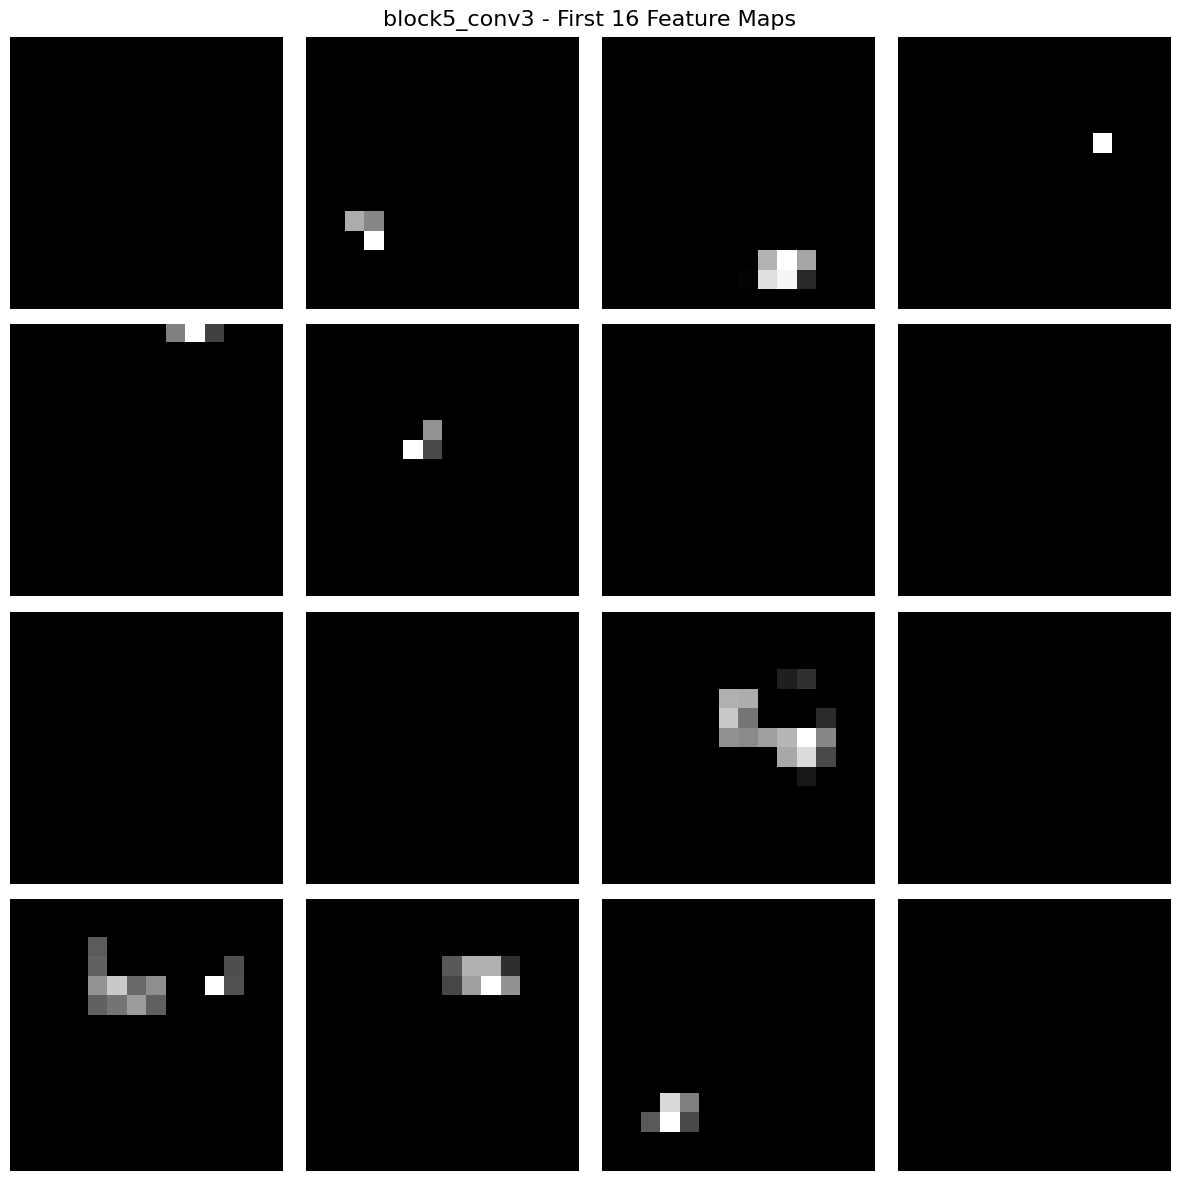

In [21]:
for layer_index, fmap in zip(layer_indices, feature_maps):

    layer_name = model.layers[layer_index].name

    n_features = min(16, fmap.shape[-1])

    fig = plt.figure(figsize=(12, 12))

    fig.suptitle(
        f"{layer_name} - First {n_features} Feature Maps",
        fontsize=16
    )

    for i in range(n_features):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            fmap[0, :, :, i],
            cmap='gray'
        )

        plt.axis('off')

    plt.tight_layout()

    plt.show()